In [79]:
import numpy as np
import pandas as pd
from glob import glob
from matplotlib import pyplot as plt
import seaborn as sns
import pickle as pkl
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from one.api import ONE
from sklearn.decomposition import PCA
from dPCA import dPCA
from sklearn.metrics import euclidean_distances
from scipy import stats

In [108]:
import warnings

warnings.filterwarnings("ignore")

In [137]:
import plotly.io as pio

pio.renderers.default = "notebook"

In [3]:
%load_ext autoreload
%autoreload 2

In [1]:
def get_region_stats():
    one = ONE()
    units_df = bwm_units(one)
    neuron_counts = units_df.groupby(["Beryl", "eid"]).size().reset_index(name="neuron_count")
    valid_pairings = neuron_counts[neuron_counts["neuron_count"] >= 5]
    # print(valid_pairings)  # atleast 10 neurons
    final_counts = (
        valid_pairings.groupby("Beryl")["eid"]
        .nunique()
        .reset_index(name="valid_eid_count")
        .sort_values(by="valid_eid_count", ascending=False)
    )
    # print(final_counts)
    regions_of_interest = final_counts[final_counts["valid_eid_count"] >= 20]["Beryl"].values
    region_totals = units_df.groupby("Beryl").size()
    valid_regions = region_totals[region_totals >= 20].index
    df_valid = units_df[units_df["Beryl"].isin(valid_regions)]

    final_table = (
        df_valid.groupby("Beryl")["eid"]
        .agg(
            total_neurons="size",
            unique_eid_count="nunique",
            eids_list=lambda x: list(x.unique()),
        )
        .reset_index()
        .sort_values(by="total_neurons", ascending=False)
    )
    # final_table[final_table["unique_eid_count"] >= 10]["Beryl"].values
    return final_table, final_counts

In [145]:
def plot_trajectories(traj_A, traj_B):
    import plotly.graph_objects as go

    trace_A = go.Scatter3d(
        x=traj_A[:, 0],
        y=traj_A[:, 1],
        z=traj_A[:, 2],
        mode="lines+markers",
        line=dict(color="blue", width=4),
        marker=dict(
            size=[8] + [2] * (len(traj_A) - 1), color="blue"
        ),  # Makes the first dot bigger
        name="Correct",
    )

    trace_B = go.Scatter3d(
        x=traj_B[:, 0],
        y=traj_B[:, 1],
        z=traj_B[:, 2],
        mode="lines+markers",
        line=dict(color="red", width=4),
        marker=dict(size=[8] + [2] * (len(traj_B) - 1), color="red"),  # Makes the first dot bigger
        name="Incorrect",
    )

    fig = go.Figure(data=[trace_A, trace_B])

    fig.update_layout(
        title="Trajectories in 3D Shared Subspace",
        scene=dict(xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="PC 3"),
        width=400,
        height=400,
    )
    fig.show()

In [146]:
def total_distance_travelled(condition):
    deltas = np.diff(condition, axis=1)
    delta_sum = np.sum(np.abs(deltas), axis=1)
    return delta_sum

In [153]:
def test_for_entire_region(filename):
    with open(filename, "rb") as f:
        data = pkl.load(f)
    data_all = []
    for eid in data.keys():
        data_all.append(data[eid])
    stiched_session = np.concatenate(data_all, axis=0)
    pca = PCA(n_components=3)
    pca.fit(stiched_session.T)

    # get region
    n_conds = 2
    n_timepoints = 50

    cond_A_data = stiched_session[:, 0:n_timepoints]
    cond_B_data = stiched_session[:, n_timepoints:]
    traj_A = pca.transform(cond_A_data.T)
    traj_B = pca.transform(cond_B_data.T)

    print(f"Explained variance is :{pca.explained_variance_}")

    # compute time resolved distance
    distance = np.linalg.norm(cond_A_data - cond_B_data, axis=0)
    print(f"Distance is {np.mean(distance)}")
    # more movement in one condition compared to the other
    # total distance
    ca = total_distance_travelled(cond_A_data)
    cb = total_distance_travelled(cond_B_data)

    sns.kdeplot(ca, label="correct")
    sns.kdeplot(cb, label="incorrect")
    plt.legend()
    sns.despine()
    plt.show()
    return traj_A, traj_B

In [154]:
files = glob("../data/generated/manifold/*.pkl")

In [156]:
# for idx, f in enumerate(files):
#     ta, tb = test_for_entire_region(f)
#     plot_trajectories(ta, tb)

#     if idx == 10:
#         break

<Axes: ylabel='Density'>

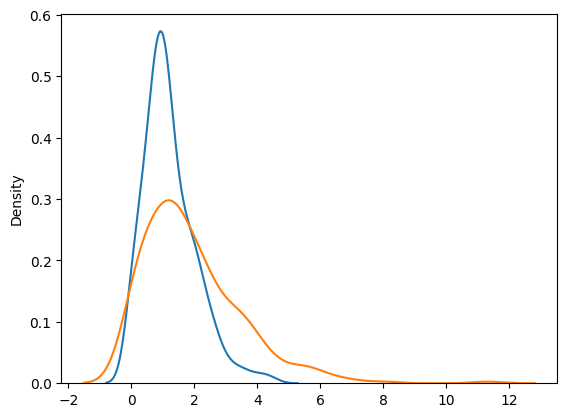

np.float64(0.969528823568109)